# 6CS012 — Final Portfolio: Image Classification
## Facial Expression Classification using CNN & Transfer Learning (ResNet50)
**Author:** Avishek kadel

---
## Imports and GPU Check

In [1]:
# Import required libraries, set random seeds, and check GPU availability.
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPUs found:', gpus)
if gpus:
    # Allow memory growth to avoid OOM errors
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print('Memory growth enabled on all GPUs')
else:
    print('WARNING: No GPU detected — training will be slow on CPU')

2026-05-07 12:25:29.936197: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 12:25:31.589234: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-07 12:25:36.218399: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled on all GPUs


---
## Dataset Paths

In [2]:
# Configure dataset paths and confirm that the required folders exist.
#  EDIT: set BASE_DIR to wherever you extracted the zip
#  Example WSL path: /home/yourname/datasets/facial_expression_classification
#  Example Windows path mounted in WSL: /mnt/c/Users/yourname/Downloads/facial_expression_classification
# ============================================================
BASE_DIR = 'facial_expression_classification'  # <-- CHANGE THIS

TRAIN_DIR      = os.path.join(BASE_DIR, 'train')
VALIDATION_DIR = os.path.join(BASE_DIR, 'validation')
TEST_DIR       = os.path.join(BASE_DIR, 'test')

# Hyperparameters
IMG_SIZE    = (48, 48)
BATCH_SIZE  = 32
NUM_CLASSES = 7

# Verify paths
for split, path in [('train', TRAIN_DIR), ('validation', VALIDATION_DIR), ('test', TEST_DIR)]:
    exists = os.path.isdir(path)
    print(f'  {split:12s}: {"OK" if exists else "NOT FOUND"} -> {path}')
    if not exists:
        print(f'    ERROR: Please fix BASE_DIR above!')

  train       : OK -> facial_expression_classification/train
  validation  : OK -> facial_expression_classification/validation
  test        : OK -> facial_expression_classification/test


---
## Data Understanding and Class Distribution

In [3]:
# Inspect class folders and count images in each split.
class_names = sorted(os.listdir(TRAIN_DIR))
print('Classes detected:', class_names)
print('Number of classes:', len(class_names))

train_counts = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in class_names}
val_counts   = {cls: len(os.listdir(os.path.join(VALIDATION_DIR, cls))) for cls in class_names}
test_counts  = {cls: len(os.listdir(os.path.join(TEST_DIR, cls))) for cls in class_names}

print('\n{:<12} {:>8} {:>12} {:>8}'.format('Class', 'Train', 'Validation', 'Test'))
print('-' * 44)
for cls in class_names:
    print('{:<12} {:>8} {:>12} {:>8}'.format(cls, train_counts[cls], val_counts[cls], test_counts[cls]))
print('-' * 44)
print('{:<12} {:>8} {:>12} {:>8}'.format('TOTAL',
    sum(train_counts.values()), sum(val_counts.values()), sum(test_counts.values())))

Classes detected: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7

Class           Train   Validation     Test
--------------------------------------------
angry            7379         1920      600
disgust           665          222      200
fear             7599         2036      600
happy           13721         3650      600
neutral          9786         2432      600
sad             11588         2278      600
surprise         7241         1594      600
--------------------------------------------
TOTAL           57979        14132     3800


In [4]:
# Validate dataset images and move corrupted files into a quarantine folder.
from pathlib import Path
from PIL import Image, UnidentifiedImageError
import shutil

# Keep this aligned with BASE_DIR used above
DATASET_DIR = Path(BASE_DIR)
QUARANTINE_DIR = DATASET_DIR / '_bad_files_quarantine'
MOVE_BAD_FILES = True

bad_files = []
valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}

if MOVE_BAD_FILES:
    QUARANTINE_DIR.mkdir(parents=True, exist_ok=True)

for file_path in DATASET_DIR.rglob('*'):
    if not file_path.is_file():
        continue

    # Ignore previously quarantined files
    if QUARANTINE_DIR in file_path.parents:
        continue

    # Ignore obvious non-image files (e.g., Zone.Identifier)
    if file_path.suffix.lower() not in valid_extensions:
        continue

    try:
        with Image.open(file_path) as img:
            img.load()
            img.convert('RGB')
    except Exception as e:
        bad_files.append((str(file_path), str(e)))
        if MOVE_BAD_FILES:
            target = QUARANTINE_DIR / file_path.name
            stem, suffix = target.stem, target.suffix
            k = 1
            while target.exists():
                target = QUARANTINE_DIR / (stem + '_' + str(k) + suffix)
                k += 1
            shutil.move(str(file_path), str(target))

print('Bad/problem image files found:', len(bad_files))
if MOVE_BAD_FILES:
    print('Quarantined into:', QUARANTINE_DIR)

for f, err in bad_files[:50]:
    print(f, '-->', err)


Bad/problem image files found: 0
Quarantined into: facial_expression_classification/_bad_files_quarantine


---
## Visualize Class Distribution

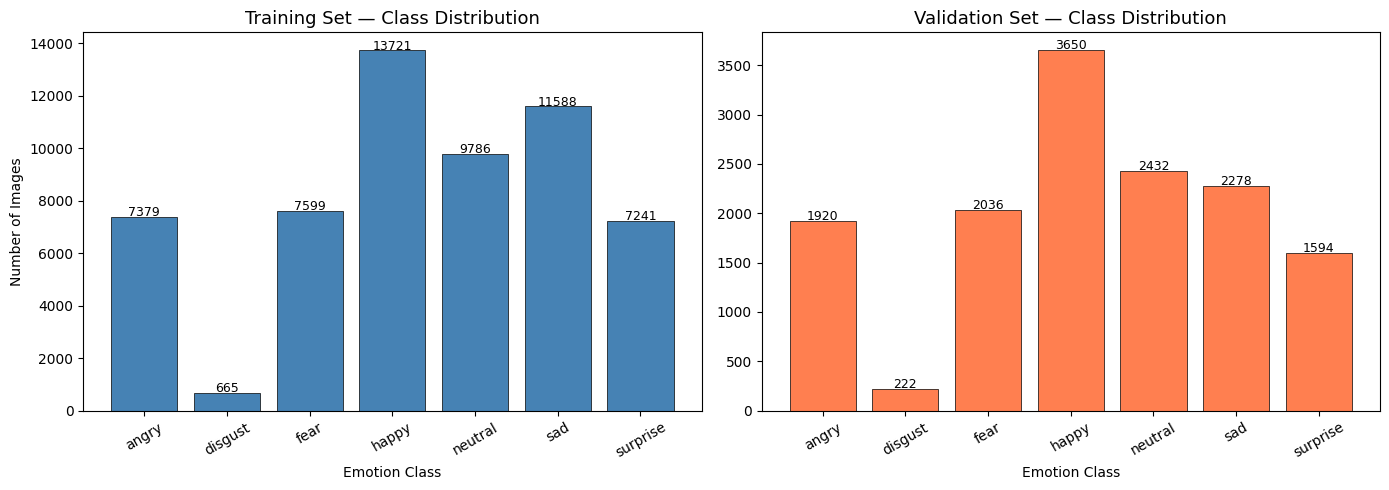

Saved: class_distribution.png


In [5]:
# Plot class distribution for the training and validation sets.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(train_counts.keys(), train_counts.values(), color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].set_title('Training Set — Class Distribution', fontsize=13)
axes[0].set_xlabel('Emotion Class')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=30)
for i, (k, v) in enumerate(train_counts.items()):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=9)

axes[1].bar(val_counts.keys(), val_counts.values(), color='coral', edgecolor='black', linewidth=0.5)
axes[1].set_title('Validation Set — Class Distribution', fontsize=13)
axes[1].set_xlabel('Emotion Class')
axes[1].tick_params(axis='x', rotation=30)
for i, (k, v) in enumerate(val_counts.items()):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_distribution.png')

---
## Visualize Sample Images

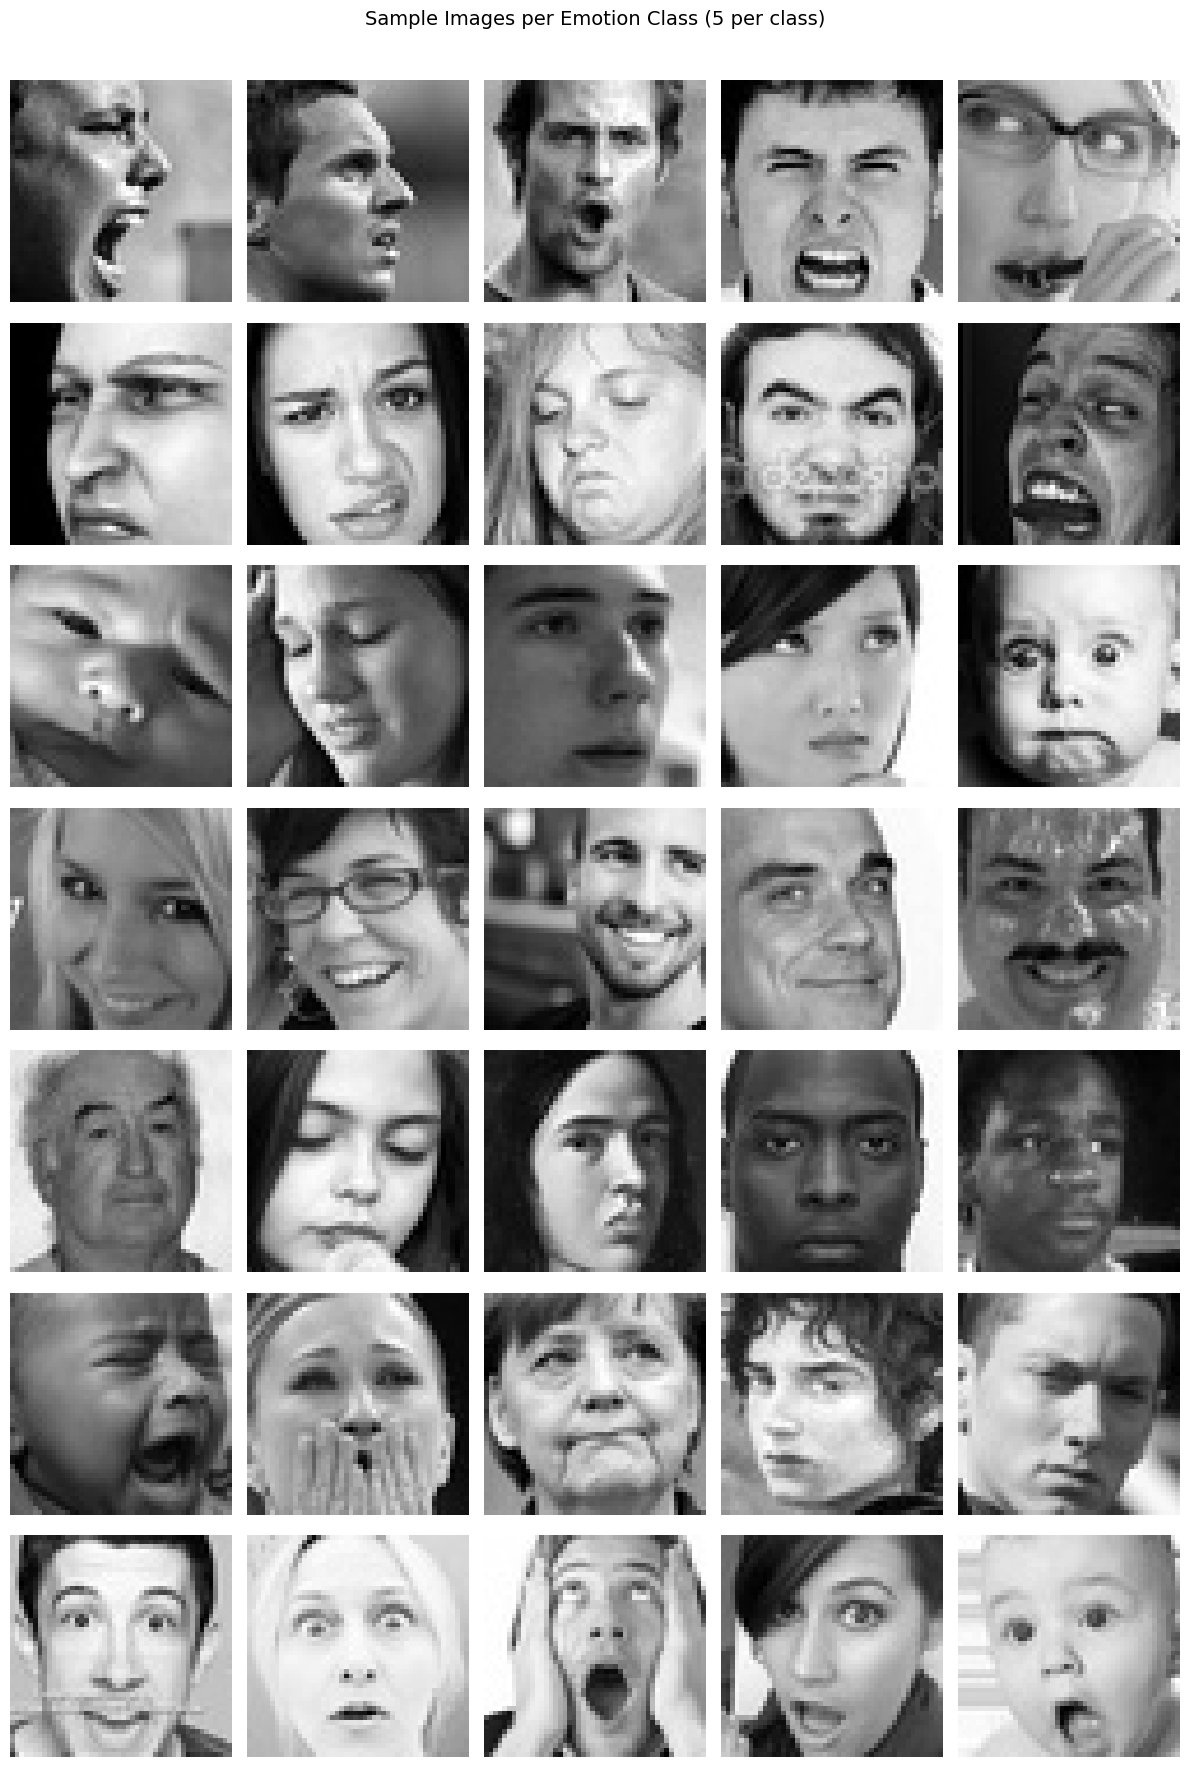

Saved: sample_images.png


In [6]:
# Display sample training images from each emotion class.
fig, axes = plt.subplots(len(class_names), 5, figsize=(12, 2.5 * len(class_names)))

for i, cls in enumerate(class_names):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:5]
    for j in range(5):
        ax = axes[i, j]
        if j < len(img_files):
            img = plt.imread(os.path.join(cls_path, img_files[j]))
            ax.imshow(img, cmap='gray')
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(cls, fontsize=11, rotation=0, labelpad=55, va='center')

plt.suptitle('Sample Images per Emotion Class (5 per class)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_images.png')

---
## Data Generators with Augmentation

In [7]:
# Create training and validation data generators with preprocessing.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.1
)

# Validation & test — only rescale, NO augmentation
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    VALIDATION_DIR,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print('\nClass index mapping:', train_gen.class_indices)
print('Train batches:', len(train_gen))
print('Val batches  :', len(val_gen))
print('Test batches :', len(test_gen))

Found 26872 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.

Class index mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Train batches: 840
Val batches  : 221
Test batches : 60


---
## Visualize Augmented Samples

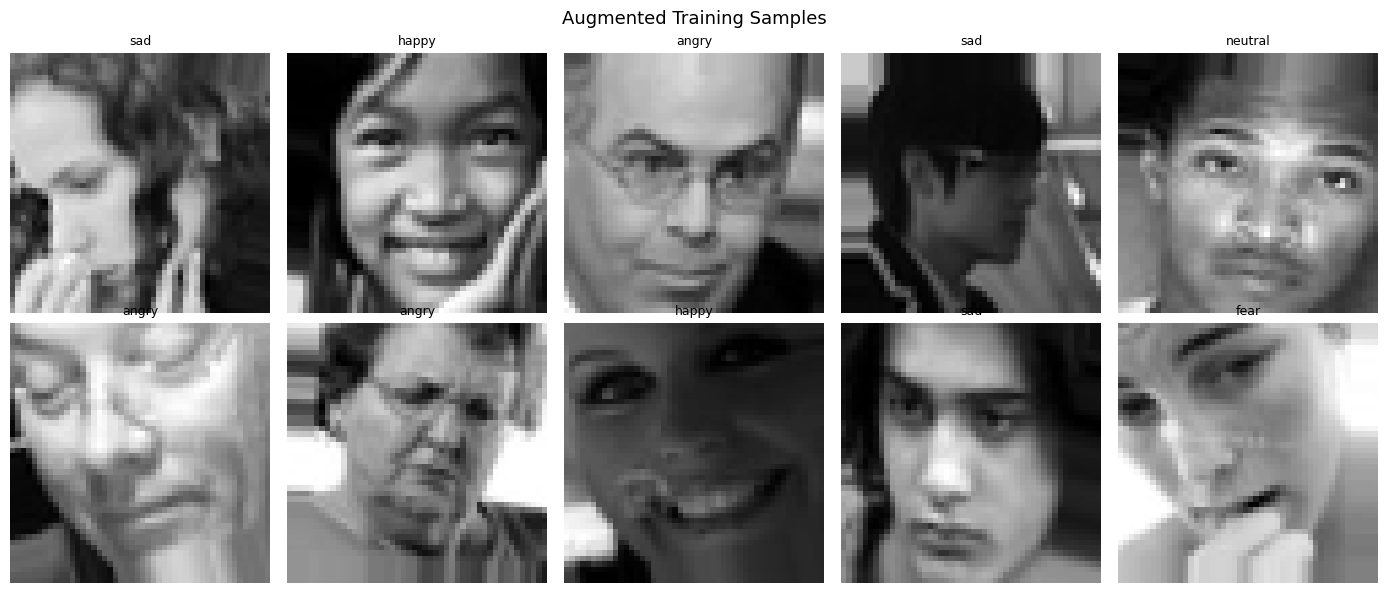

Saved: augmented_samples.png


In [8]:
# Visualize augmented training images to check augmentation quality.
sample_images, sample_labels = next(train_gen)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_images[i].squeeze(), cmap='gray')
    ax.set_title(class_names[np.argmax(sample_labels[i])], fontsize=9)
    ax.axis('off')

plt.suptitle('Augmented Training Samples', fontsize=13)
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: augmented_samples.png')

---
## Helper Functions

In [9]:
# Define helper functions for plots, evaluation, and sample predictions.
def plot_history(history, title):
    """Plot training vs validation accuracy and loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history.history['accuracy'], label='Train', linewidth=1.5)
    axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=1.5)
    axes[0].set_title(f'{title} — Accuracy', fontsize=12)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train', linewidth=1.5)
    axes[1].plot(history.history['val_loss'], label='Validation', linewidth=1.5)
    axes[1].set_title(f'{title} — Loss', fontsize=12)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    fname = title.replace(' ', '_').replace('(', '').replace(')', '') + '_curves.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


def evaluate_model(model, gen, name, class_names):
    """Evaluate model and print classification report + confusion matrix."""
    gen.reset()
    preds = model.predict(gen, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    y_true = gen.classes

    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{name} — Confusion Matrix', fontsize=13)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    fname = name.replace(' ', '_') + '_confusion.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')
    return y_true, y_pred


def show_predictions(model, gen, class_names, title='Predictions', n=10):
    """Show sample predictions with true vs predicted labels."""
    gen.reset()
    images, labels = next(gen)
    preds = model.predict(images[:n], verbose=0)

    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    for i, ax in enumerate(axes.flatten()):
        if i >= n:
            ax.axis('off')
            continue
        ax.imshow(images[i].squeeze(), cmap='gray')
        true_label = class_names[np.argmax(labels[i])]
        pred_label = class_names[np.argmax(preds[i])]
        conf = np.max(preds[i]) * 100
        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f'T: {true_label}\nP: {pred_label} ({conf:.0f}%)', fontsize=8, color=color)
        ax.axis('off')

    plt.suptitle(f'{title} — green=correct, red=wrong', fontsize=11)
    plt.tight_layout()
    fname = title.replace(' ', '_') + '_predictions.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


# Shared callbacks used for all models
def get_callbacks(checkpoint_name):
    return [
        EarlyStopping(patience=10, restore_best_weights=True, monitor='val_accuracy', verbose=1),
        ReduceLROnPlateau(factor=0.5, patience=5, monitor='val_loss', verbose=1, min_lr=1e-7),
        ModelCheckpoint(checkpoint_name, save_best_only=True, monitor='val_accuracy', verbose=0)
    ]

print('Helper functions defined successfully.')

Helper functions defined successfully.


---
## Part A: Build Baseline CNN

In [10]:
# Build a baseline CNN model with three convolutional blocks.
def build_baseline_cnn(num_classes):
    """
    Baseline CNN as required by Part A:
    - 3 Convolutional layers each followed by Pooling
    - 3 Fully Connected layers
    - Output layer
    """
    model = keras.Sequential([
        # Conv Block 1 — 32 filters, 3x3 kernel, ReLU
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=(48, 48, 1), name='conv1'),
        layers.MaxPooling2D(2, 2, name='pool1'),

        # Conv Block 2 — 64 filters, 3x3 kernel, ReLU
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
        layers.MaxPooling2D(2, 2, name='pool2'),

        # Conv Block 3 — 128 filters, 3x3 kernel, ReLU
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),
        layers.MaxPooling2D(2, 2, name='pool3'),

        # Flatten
        layers.Flatten(name='flatten'),

        # FCN 1
        layers.Dense(256, activation='relu', name='fc1'),
        # FCN 2
        layers.Dense(128, activation='relu', name='fc2'),
        # FCN 3
        layers.Dense(64, activation='relu', name='fc3'),

        # Output
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='Baseline_CNN')
    return model


baseline_model = build_baseline_cnn(NUM_CLASSES)
baseline_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()

/home/animeshbaral/AI/tfenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778157042.993937    1234 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,183 (5.01 MB)

 Trainable params: 1,314,183 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

---
## Train Baseline CNN

In [12]:
# Train the baseline CNN and record elapsed training time.
print('Training Baseline CNN...')
start = time.time()

baseline_history = baseline_model.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    callbacks=get_callbacks('best_baseline_cnn.keras')
)

baseline_time = time.time() - start
print(f'\nBaseline training time: {baseline_time/60:.1f} minutes')
print(f'Best val accuracy: {max(baseline_history.history["val_accuracy"]):.4f}')

Training Baseline CNN...
Epoch 1/50
840/840 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.5123 - loss: 1.2706 - val_accuracy: 0.5426 - val_loss: 1.2095 - learning_rate: 0.0010
Epoch 2/50
840/840 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.5201 - loss: 1.2429 - val_accuracy: 0.5491 - val_loss: 1.1872 - learning_rate: 0.0010
Epoch 3/50
840/840 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5333 - loss: 1.2176 - val_accuracy: 0.5631 - val_loss: 1.1495 - learning_rate: 0.0010
Epoch 4/50
840/840 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.5437 - loss: 1.1999 - val_accuracy: 0.5611 - val_loss: 1.1419 - learning_rate: 0.0010
Epoch 5/50
840/840 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5498 - loss: 1.1778 - val_accuracy: 0.5662 - val_loss: 1.1415 - learning_rate: 0.0010
Epoch 6/50
840/840 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.5539 - loss: 1.1658 - val_accuracy: 0.5723 - val_loss: 1.1330 - learning_rate: 0.0010
Epoch 7/50
840/840 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/st

---
## Plot and Evaluate Baseline CNN

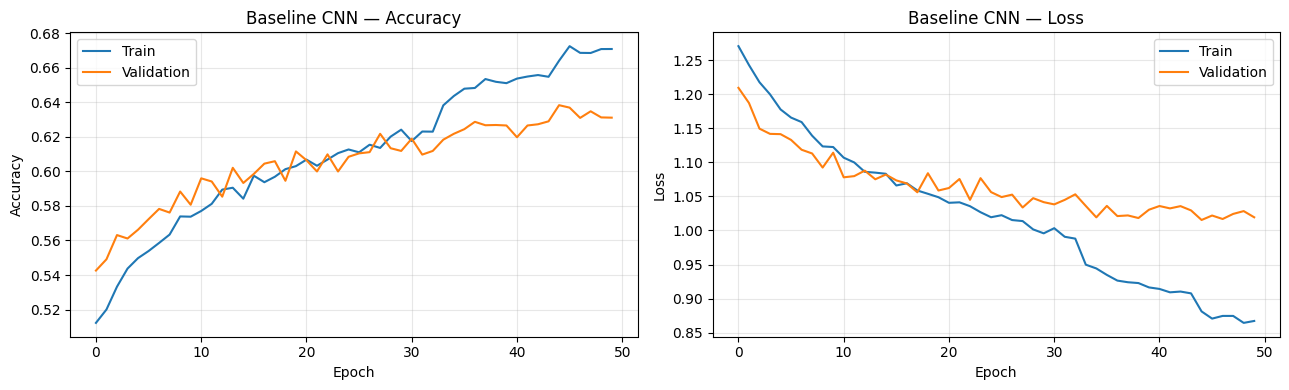

Saved: Baseline_CNN_curves.png
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step

  Baseline CNN
              precision    recall  f1-score   support

       angry     0.5624    0.5260    0.5436       960
     disgust     0.5447    0.6036    0.5726       111
        fear     0.5930    0.3507    0.4407      1018
       happy     0.8288    0.8542    0.8413      1825
     neutral     0.5232    0.6678    0.5867      1216
         sad     0.5017    0.5198    0.5106      1139
    surprise     0.7446    0.7754    0.7597       797

    accuracy                         0.6383      7066
   macro avg     0.6141    0.6139    0.6079      7066
weighted avg     0.6394    0.6383    0.6326      7066



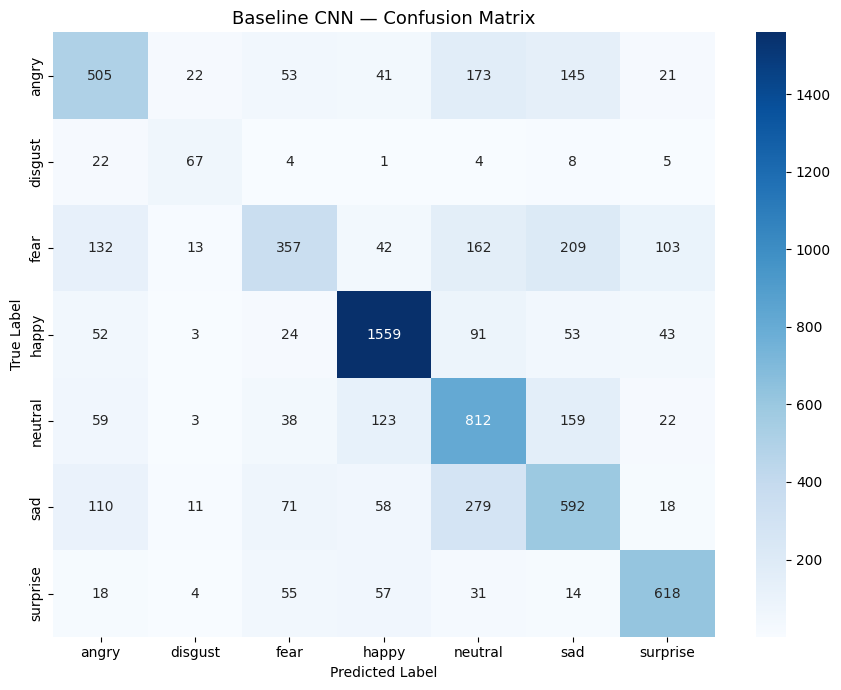

Saved: Baseline_CNN_confusion.png


2026-05-07 12:45:35.822864: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_79', 16 bytes spill stores, 16 bytes spill loads

2026-05-07 12:45:35.902044: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_79', 8 bytes spill stores, 8 bytes spill loads



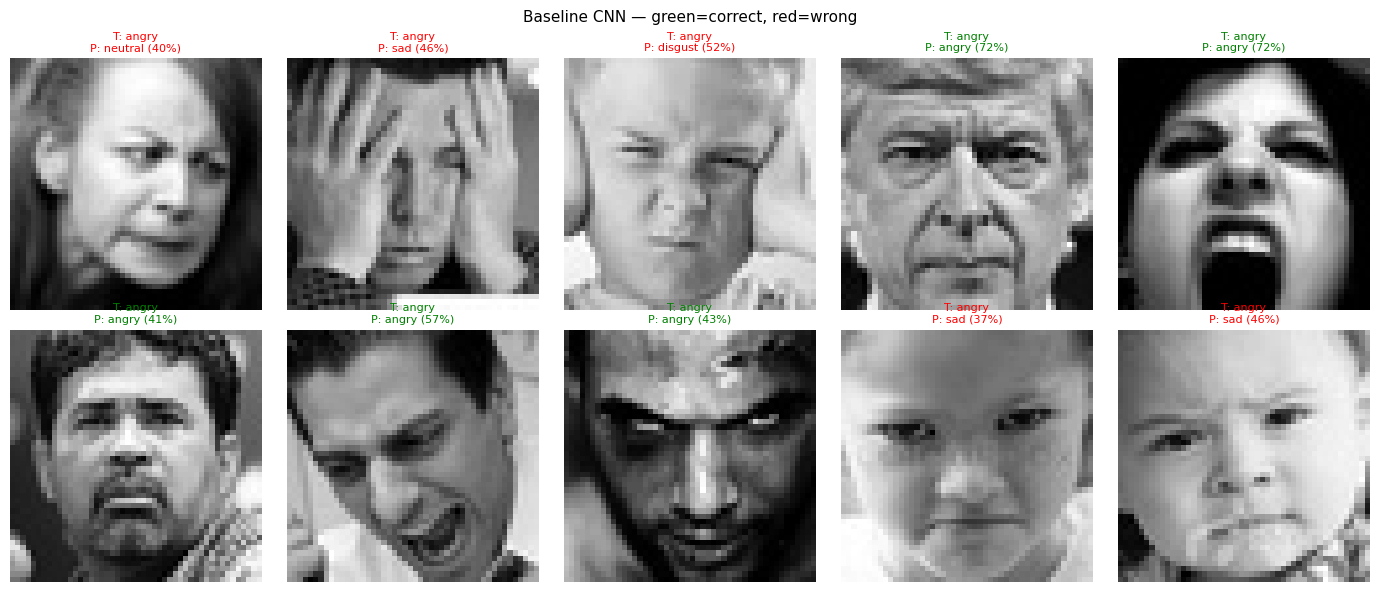

Saved: Baseline_CNN_predictions.png


In [13]:
# Plot baseline training history and evaluate validation performance.
plot_history(baseline_history, 'Baseline CNN')
baseline_true, baseline_pred = evaluate_model(baseline_model, val_gen, 'Baseline CNN', class_names)
show_predictions(baseline_model, val_gen, class_names, title='Baseline CNN')

---
## Part A: Build Deeper CNN with BatchNorm and Dropout

In [14]:
# Build a deeper CNN with BatchNorm and Dropout regularization.
def build_deeper_cnn(num_classes, optimizer='adam'):
    """
    Deeper CNN — at least double the layers of baseline:
    - 8 Conv layers (vs 3 in baseline)
    - BatchNormalization after each Conv
    - Dropout for regularization
    """
    model = keras.Sequential([
        # Block 1 — 32 filters (double conv)
        layers.Conv2D(32, (3,3), padding='same', input_shape=(48, 48, 1)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 2 — 64 filters (double conv)
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 3 — 128 filters (double conv)
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 4 — 256 filters (double conv)
        layers.Conv2D(256, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(256, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.3),

        # Classifier Head
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ], name='Deeper_CNN')

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


deeper_model = build_deeper_cnn(NUM_CLASSES, optimizer=Adam(learning_rate=1e-3))
deeper_model.summary()

/home/animeshbaral/AI/tfenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 12, 12, 128)    │             

 Total params: 2,490,855 (9.50 MB)

 Trainable params: 2,487,911 (9.49 MB)

 Non-trainable params: 2,944 (11.50 KB)

---
## Train Deeper CNN with Adam

In [16]:
# Train the deeper CNN using the Adam optimizer.
print('Training Deeper CNN with Adam...')
start = time.time()

deeper_history = deeper_model.fit(
    train_gen,
    epochs=60,
    validation_data=val_gen,
    callbacks=get_callbacks('best_deeper_cnn_adam.keras')
)

deeper_time = time.time() - start
print(f'\nDeeper CNN (Adam) training time: {deeper_time/60:.1f} minutes')
print(f'Best val accuracy: {max(deeper_history.history["val_accuracy"]):.4f}')

Training Deeper CNN with Adam...
Epoch 1/60
840/840 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.6063 - loss: 1.0646 - val_accuracy: 0.5863 - val_loss: 1.1284 - learning_rate: 0.0010
Epoch 2/60
840/840 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.6033 - loss: 1.0552 - val_accuracy: 0.6202 - val_loss: 1.0289 - learning_rate: 0.0010
Epoch 3/60
840/840 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.6120 - loss: 1.0503 - val_accuracy: 0.5773 - val_loss: 1.1572 - learning_rate: 0.0010
Epoch 4/60
840/840 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.6135 - loss: 1.0431 - val_accuracy: 0.6175 - val_loss: 1.0243 - learning_rate: 0.0010
Epoch 5/60
840/840 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.6194 - loss: 1.0277 - val_accuracy: 0.6315 - val_loss: 0.9771 - learning_rate: 0.0010
Epoch 6/60
840/840 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.6211 - loss: 1.0265 - val_accuracy: 0.6158 - val_loss: 1.0054 - learning_rate: 0.0010
Epoch 7/60
840/840 ━━━━━━━━━━━━━━━━━━━━ 12s

---
## Plot and Evaluate Deeper CNN with Adam

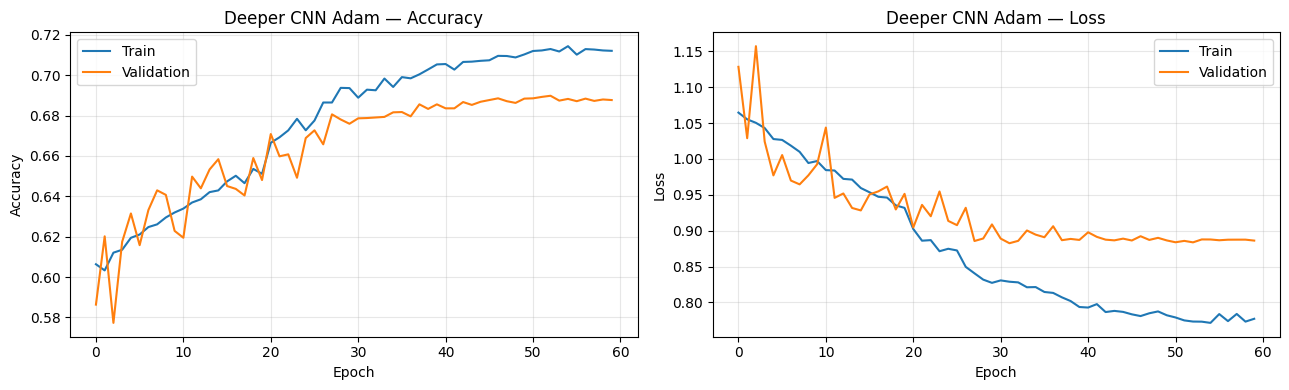

Saved: Deeper_CNN_Adam_curves.png
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step

  Deeper CNN Adam
              precision    recall  f1-score   support

       angry     0.5881    0.6188    0.6030       960
     disgust     0.8000    0.5405    0.6452       111
        fear     0.5975    0.4155    0.4902      1018
       happy     0.8942    0.8888    0.8915      1825
     neutral     0.5795    0.7582    0.6569      1216
         sad     0.5842    0.5698    0.5769      1139
    surprise     0.7979    0.7578    0.7773       797

    accuracy                         0.6898      7066
   macro avg     0.6916    0.6499    0.6630      7066
weighted avg     0.6934    0.6898    0.6866      7066



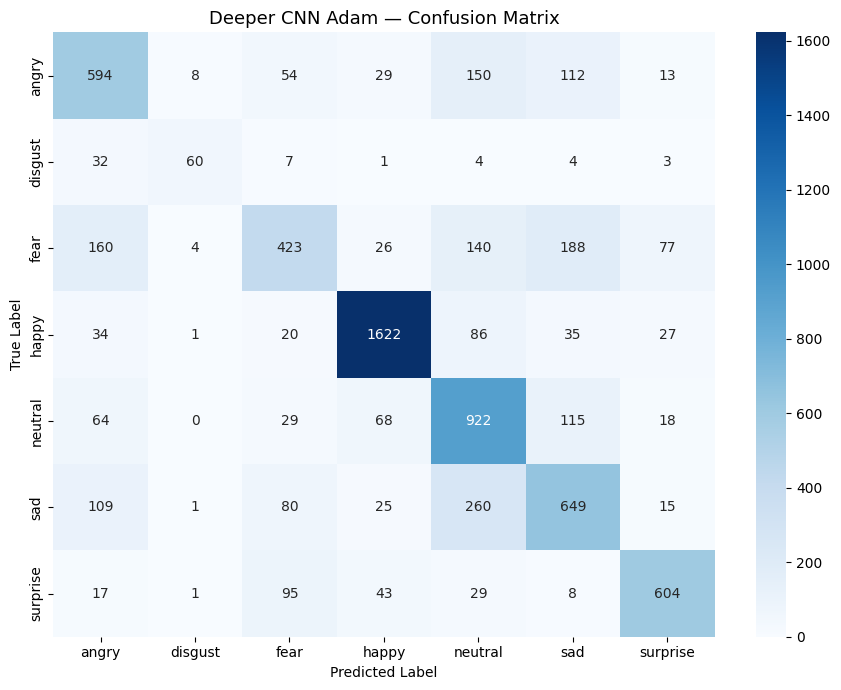

Saved: Deeper_CNN_Adam_confusion.png


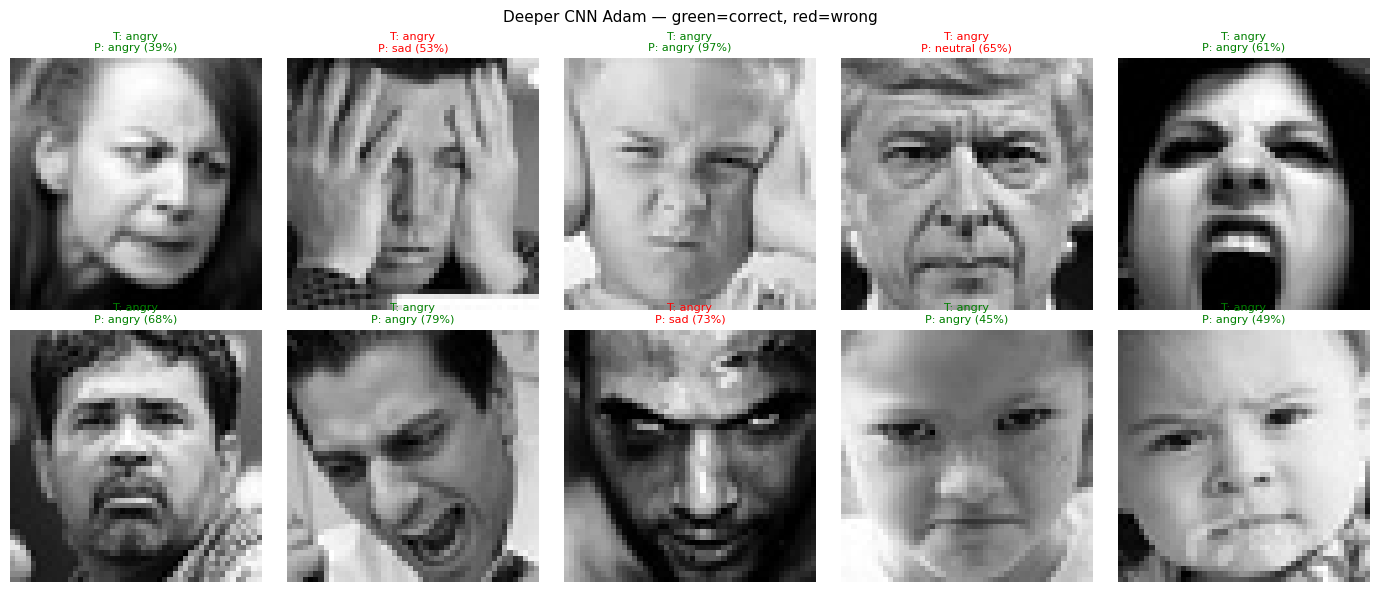

Saved: Deeper_CNN_Adam_predictions.png


In [17]:
# Plot and evaluate the deeper CNN trained with Adam.
plot_history(deeper_history, 'Deeper CNN Adam')
deeper_true, deeper_pred = evaluate_model(deeper_model, val_gen, 'Deeper CNN Adam', class_names)
show_predictions(deeper_model, val_gen, class_names, title='Deeper CNN Adam')

---
## Optimizer Comparison with SGD

In [18]:
# Train the deeper CNN with SGD for optimizer comparison.
sgd_optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
sgd_model = build_deeper_cnn(NUM_CLASSES, optimizer=sgd_optimizer)

print('Training Deeper CNN with SGD (momentum=0.9, nesterov=True)...')
start = time.time()

sgd_history = sgd_model.fit(
    train_gen,
    epochs=60,
    validation_data=val_gen,
    callbacks=get_callbacks('best_deeper_cnn_sgd.keras')
)

sgd_time = time.time() - start
print(f'\nDeeper CNN (SGD) training time: {sgd_time/60:.1f} minutes')
print(f'Best val accuracy: {max(sgd_history.history["val_accuracy"]):.4f}')

/home/animeshbaral/AI/tfenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Deeper CNN with SGD (momentum=0.9, nesterov=True)...
Epoch 1/60


2026-05-07 13:06:53.668181: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-07 13:06:53.668252: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-07 13:06:55.029200: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5356', 520 bytes spill stores, 520 bytes spill loads

2026-05-07 13:06:55.110539: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning

840/840 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.2245 - loss: 1.9212 - val_accuracy: 0.2791 - val_loss: 1.7652 - learning_rate: 0.0100
Epoch 2/60
840/840 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.2613 - loss: 1.7899 - val_accuracy: 0.3106 - val_loss: 1.7042 - learning_rate: 0.0100
Epoch 3/60
840/840 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.2954 - loss: 1.7229 - val_accuracy: 0.2740 - val_loss: 1.7845 - learning_rate: 0.0100
Epoch 4/60
840/840 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.3399 - loss: 1.6513 - val_accuracy: 0.3514 - val_loss: 1.6698 - learning_rate: 0.0100
Epoch 5/60
840/840 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.3760 - loss: 1.5754 - val_accuracy: 0.3882 - val_loss: 1.5886 - learning_rate: 0.0100
Epoch 6/60
840/840 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.4087 - loss: 1.5048 - val_accuracy: 0.4493 - val_loss: 1.4734 - learning_rate: 0.0100
Epoch 7/60
840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.4329 - loss: 1.4584

---
## Plot Optimizer Comparison

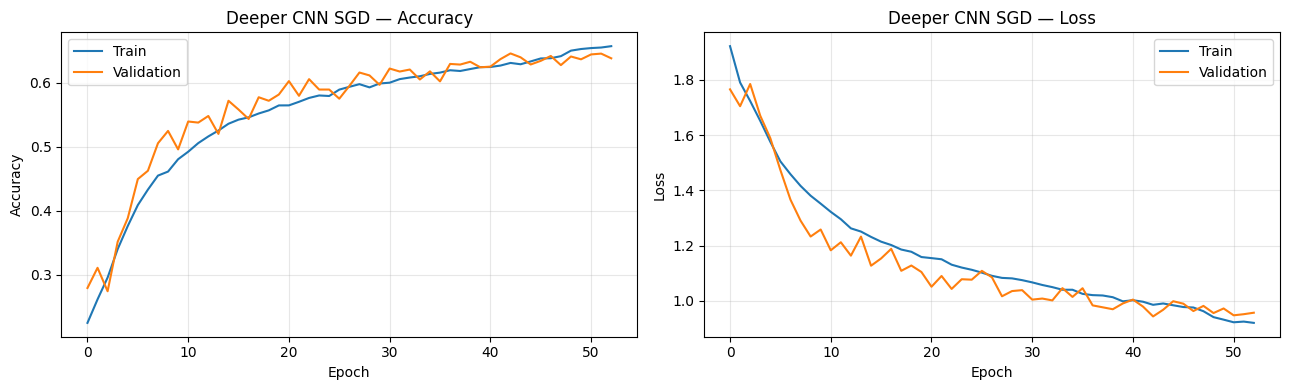

Saved: Deeper_CNN_SGD_curves.png
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step

  Deeper CNN SGD
              precision    recall  f1-score   support

       angry     0.5355    0.5729    0.5536       960
     disgust     0.6591    0.2613    0.3742       111
        fear     0.5516    0.3988    0.4629      1018
       happy     0.8628    0.8581    0.8604      1825
     neutral     0.5092    0.7706    0.6132      1216
         sad     0.5605    0.4311    0.4873      1139
    surprise     0.8022    0.7327    0.7659       797

    accuracy                         0.6458      7066
   macro avg     0.6401    0.5751    0.5882      7066
weighted avg     0.6539    0.6458    0.6405      7066



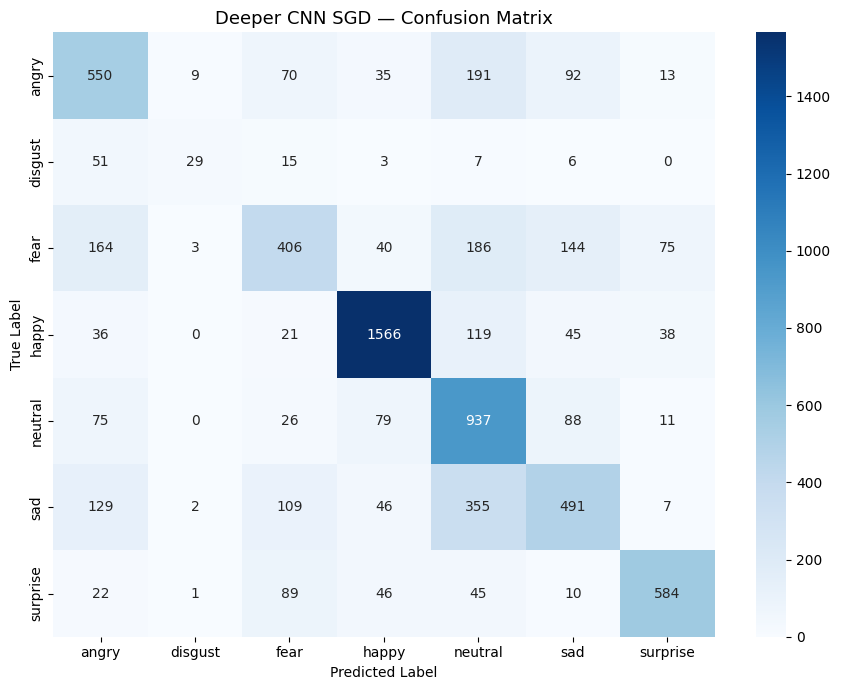

Saved: Deeper_CNN_SGD_confusion.png


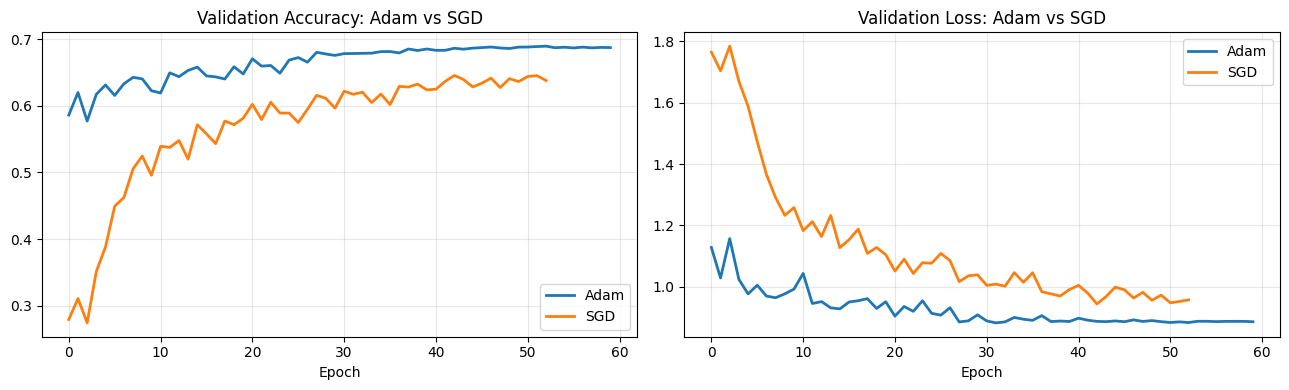

Saved: optimizer_comparison.png


In [19]:
# Plot SGD results and compare validation performance against Adam.
plot_history(sgd_history, 'Deeper CNN SGD')
sgd_true, sgd_pred = evaluate_model(sgd_model, val_gen, 'Deeper CNN SGD', class_names)

# Side-by-side Adam vs SGD
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(deeper_history.history['val_accuracy'], label='Adam', linewidth=2)
axes[0].plot(sgd_history.history['val_accuracy'],    label='SGD',  linewidth=2)
axes[0].set_title('Validation Accuracy: Adam vs SGD')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(deeper_history.history['val_loss'], label='Adam', linewidth=2)
axes[1].plot(sgd_history.history['val_loss'],    label='SGD',  linewidth=2)
axes[1].set_title('Validation Loss: Adam vs SGD')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: optimizer_comparison.png')

---
## Ablation Study: Remove Dropout

Training Ablation model (no Dropout)...
Epoch 1/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.3271 - loss: 1.7278 - val_accuracy: 0.2871 - val_loss: 1.8431 - learning_rate: 0.0010
Epoch 2/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.4717 - loss: 1.3656 - val_accuracy: 0.4997 - val_loss: 1.3194 - learning_rate: 0.0010
Epoch 3/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.5244 - loss: 1.2493 - val_accuracy: 0.5192 - val_loss: 1.2734 - learning_rate: 0.0010
Epoch 4/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5512 - loss: 1.1792 - val_accuracy: 0.5468 - val_loss: 1.1905 - learning_rate: 0.0010
Epoch 5/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.5751 - loss: 1.1206 - val_accuracy: 0.5914 - val_loss: 1.0894 - learning_rate: 0.0010
Epoch 6/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.5886 - loss: 1.0882 - val_accuracy: 0.5836 - val_loss: 1.0931 - learning_rate: 0.0010
Epoch 7/40
840/840 ━━━━━━━━━━━━━━━━━

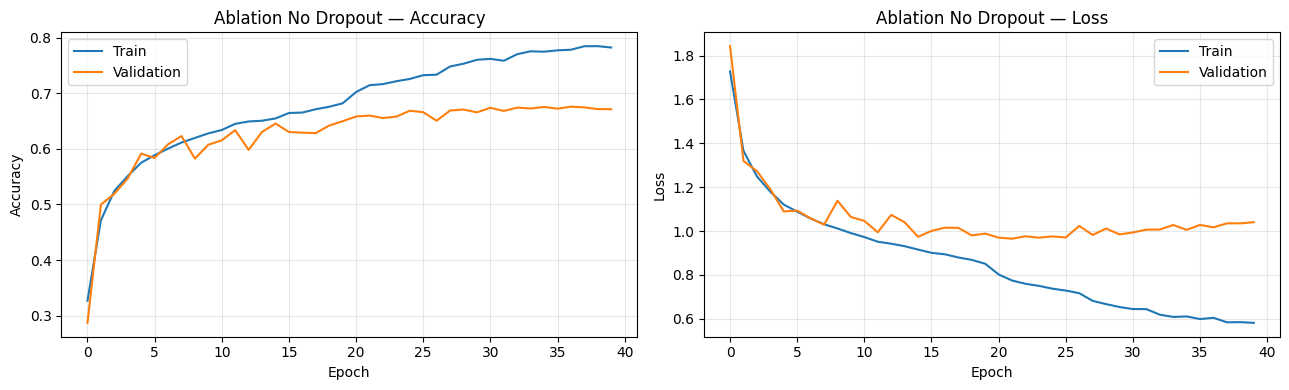

Saved: Ablation_No_Dropout_curves.png
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

  Ablation No Dropout
              precision    recall  f1-score   support

       angry     0.6076    0.5646    0.5853       960
     disgust     0.8451    0.5405    0.6593       111
        fear     0.5402    0.4823    0.5096      1018
       happy     0.8752    0.8762    0.8757      1825
     neutral     0.5810    0.6933    0.6322      1216
         sad     0.5529    0.5549    0.5539      1139
    surprise     0.7878    0.7641    0.7758       797

    accuracy                         0.6759      7066
   macro avg     0.6843    0.6394    0.6560      7066
weighted avg     0.6777    0.6759    0.6751      7066



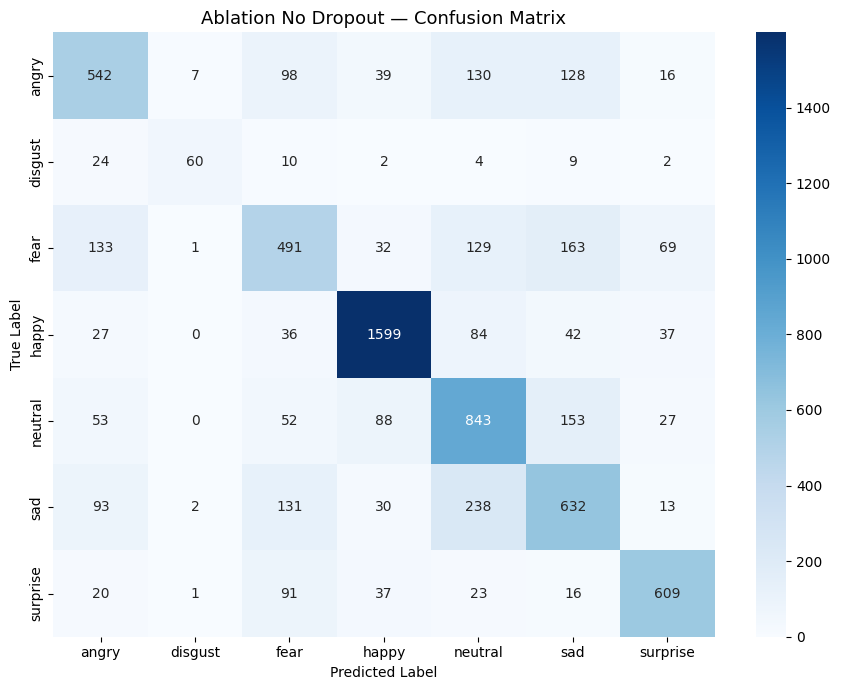

Saved: Ablation_No_Dropout_confusion.png


In [21]:
# Build and train a no-Dropout ablation model to study overfitting.
def build_no_dropout_cnn(num_classes):
    """Ablation: Deeper CNN without Dropout to study overfitting impact."""
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(48,48,1)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='No_Dropout_CNN')

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


ablation_model = build_no_dropout_cnn(NUM_CLASSES)
print('Training Ablation model (no Dropout)...')
ablation_history = ablation_model.fit(
    train_gen,
    epochs=40,
    validation_data=val_gen,
    callbacks=get_callbacks('best_ablation.keras')
)
plot_history(ablation_history, 'Ablation No Dropout')
ablation_true, ablation_pred = evaluate_model(ablation_model, val_gen, 'Ablation No Dropout', class_names)

---
## Part B: ResNet50 Data Generators

In [22]:
# Create RGB 224x224 generators required for ResNet50 transfer learning.
resnet_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
resnet_val_datagen = ImageDataGenerator(rescale=1./255)

train_gen_resnet = resnet_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(224, 224), color_mode='rgb',
    batch_size=32, class_mode='categorical', shuffle=True
)
val_gen_resnet = resnet_val_datagen.flow_from_directory(
    VALIDATION_DIR, target_size=(224, 224), color_mode='rgb',
    batch_size=32, class_mode='categorical', shuffle=False
)
test_gen_resnet = resnet_val_datagen.flow_from_directory(
    TEST_DIR, target_size=(224, 224), color_mode='rgb',
    batch_size=32, class_mode='categorical', shuffle=False
)
print('ResNet generators ready.')

Found 26872 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.
ResNet generators ready.


---
## Part B: Build ResNet50 Transfer Learning Model

In [23]:
# Build a ResNet50 transfer-learning model with a custom classification head.
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Phase 1: Freeze entire base — only train our custom head
base_model.trainable = False

# Build model with custom classification head
inputs  = keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)      # training=False keeps BN layers frozen
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = keras.Model(inputs, outputs, name='ResNet50_Transfer')

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Trainable layers (Phase 1 — feature extraction):', 
      sum(1 for l in resnet_model.layers if l.trainable))
resnet_model.summary()

Trainable layers (Phase 1 — feature extraction): 6


Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,115,079 (91.99 MB)

 Trainable params: 526,855 (2.01 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

---
## Phase 1: Feature Extraction

Phase 1: Training custom head with frozen ResNet50 base...
Epoch 1/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 176s 209ms/step - accuracy: 0.3339 - loss: 1.6730 - val_accuracy: 0.2782 - val_loss: 2.7858 - learning_rate: 0.0010
Epoch 2/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 174s 206ms/step - accuracy: 0.3366 - loss: 1.6691 - val_accuracy: 0.2584 - val_loss: 4.2780 - learning_rate: 0.0010
Epoch 3/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 202s 209ms/step - accuracy: 0.3376 - loss: 1.6593 - val_accuracy: 0.1354 - val_loss: 3.9714 - learning_rate: 0.0010
Epoch 4/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 170s 203ms/step - accuracy: 0.3414 - loss: 1.6581 - val_accuracy: 0.1268 - val_loss: 2.5642 - learning_rate: 0.0010
Epoch 5/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 174s 207ms/step - accuracy: 0.3428 - loss: 1.6559 - val_accuracy: 0.3095 - val_loss: 2.0640 - learning_rate: 0.0010
Epoch 6/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 175s 208ms/step - accuracy: 0.3448 - loss: 1.6478 - val_accuracy: 0.3174 - val_loss: 1.8891 - learning_rate: 0.0010
Epoch

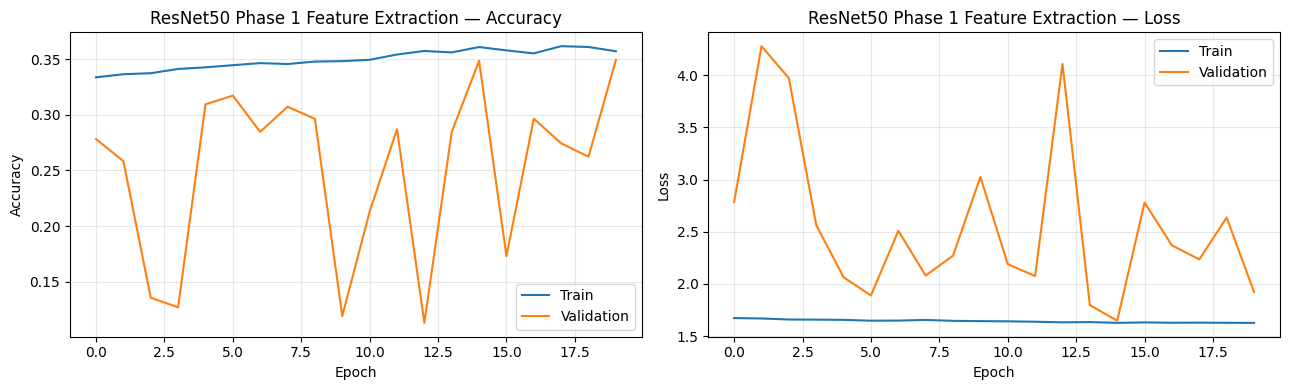

Saved: ResNet50_Phase_1_Feature_Extraction_curves.png


In [26]:
# Train the custom classification head while keeping ResNet50 frozen.
print('Phase 1: Training custom head with frozen ResNet50 base...')
start = time.time()

phase1_history = resnet_model.fit(
    train_gen_resnet,
    epochs=20,
    validation_data=val_gen_resnet,
    callbacks=get_callbacks('best_resnet_phase1.keras')
)

phase1_time = time.time() - start
print(f'\nPhase 1 time: {phase1_time/60:.1f} minutes')
print(f'Best val accuracy: {max(phase1_history.history["val_accuracy"]):.4f}')
plot_history(phase1_history, 'ResNet50 Phase 1 Feature Extraction')

---
## Phase 2: Fine-Tuning

Trainable layers after unfreezing: 30
Phase 2: Fine-tuning last 30 layers of ResNet50...
Epoch 1/30
678/840 ━━━━━━━━━━━━━━━━━━━━ 31s 193ms/step - accuracy: 0.2561 - loss: 1.9827

2026-05-07 14:57:34.480264: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7610', 4 bytes spill stores, 4 bytes spill loads



840/840 ━━━━━━━━━━━━━━━━━━━━ 214s 229ms/step - accuracy: 0.2871 - loss: 1.8567 - val_accuracy: 0.2920 - val_loss: 1.7470 - learning_rate: 1.0000e-05
Epoch 2/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 183s 217ms/step - accuracy: 0.3296 - loss: 1.7262 - val_accuracy: 0.3353 - val_loss: 1.6845 - learning_rate: 1.0000e-05
Epoch 3/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 177s 211ms/step - accuracy: 0.3517 - loss: 1.6842 - val_accuracy: 0.3327 - val_loss: 1.7873 - learning_rate: 1.0000e-05
Epoch 4/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 181s 215ms/step - accuracy: 0.3595 - loss: 1.6668 - val_accuracy: 0.3483 - val_loss: 1.5917 - learning_rate: 1.0000e-05
Epoch 5/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 176s 212ms/step - accuracy: 0.3641 - loss: 1.6465 - val_accuracy: 0.3268 - val_loss: 1.8833 - learning_rate: 1.0000e-05
Epoch 6/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 177s 210ms/step - accuracy: 0.3747 - loss: 1.6261 - val_accuracy: 0.2958 - val_loss: 1.8514 - learning_rate: 1.0000e-05
Epoch 7/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 180s 214ms/

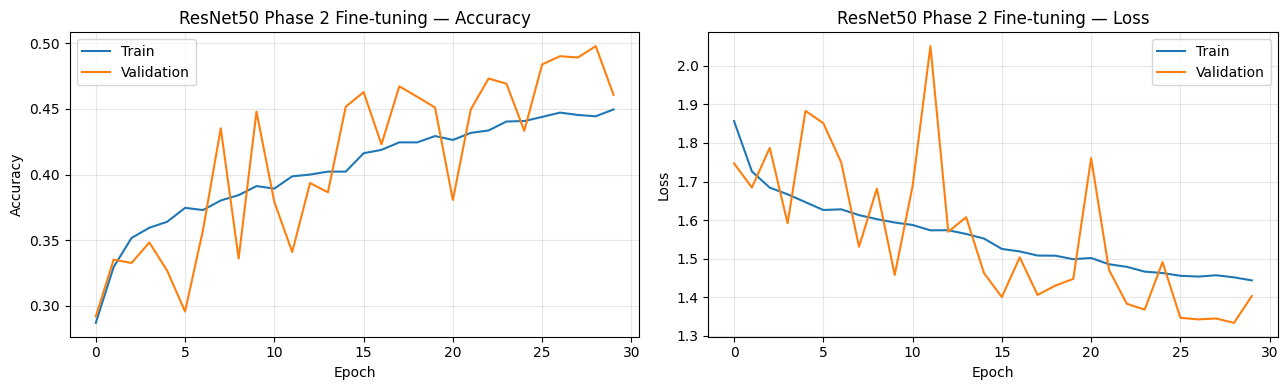

Saved: ResNet50_Phase_2_Fine-tuning_curves.png


In [27]:
# Fine-tune the model by unfreezing the top ResNet50 layers.
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print('Trainable layers after unfreezing:', sum(1 for l in base_model.layers if l.trainable))

# IMPORTANT: recompile with a much lower learning rate to avoid catastrophic forgetting
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Phase 2: Fine-tuning last 30 layers of ResNet50...')
start = time.time()

phase2_history = resnet_model.fit(
    train_gen_resnet,
    epochs=30,
    validation_data=val_gen_resnet,
    callbacks=get_callbacks('best_resnet_phase2.keras')
)

phase2_time = time.time() - start
print(f'\nPhase 2 time: {phase2_time/60:.1f} minutes')
print(f'Best val accuracy: {max(phase2_history.history["val_accuracy"]):.4f}')
plot_history(phase2_history, 'ResNet50 Phase 2 Fine-tuning')

---
## Evaluate Fine-tuned ResNet50 Model

221/221 ━━━━━━━━━━━━━━━━━━━━ 30s 98ms/step

  ResNet50 Fine-tuned
              precision    recall  f1-score   support

       angry     0.4912    0.1750    0.2581       960
     disgust     0.5000    0.0090    0.0177       111
        fear     0.3402    0.2583    0.2937      1018
       happy     0.5884    0.8170    0.6841      1825
     neutral     0.4367    0.5592    0.4904      1216
         sad     0.3955    0.3240    0.3562      1139
    surprise     0.5892    0.6838    0.6330       797

    accuracy                         0.4977      7066
   macro avg     0.4773    0.4038    0.3905      7066
weighted avg     0.4809    0.4977    0.4676      7066



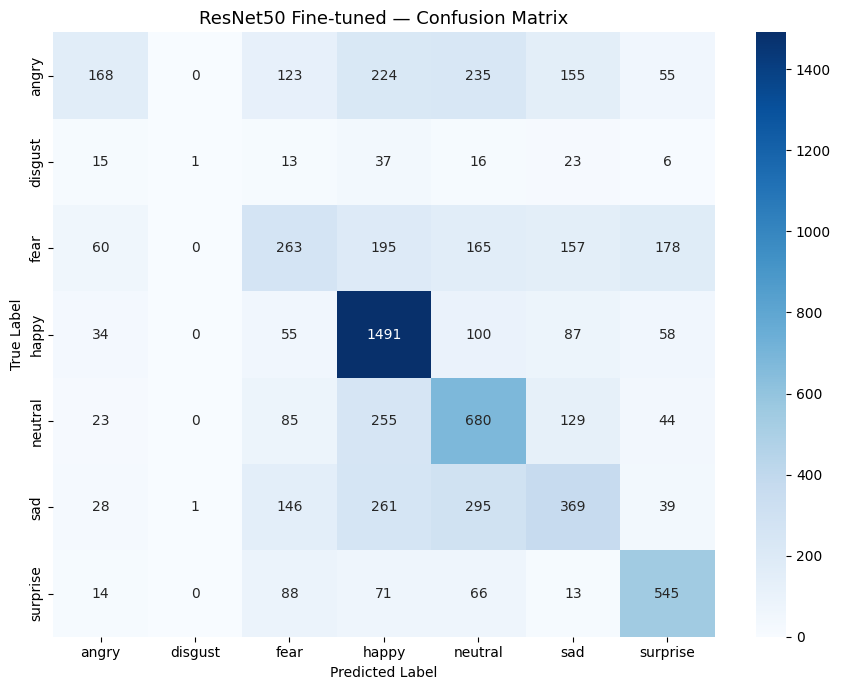

Saved: ResNet50_Fine-tuned_confusion.png


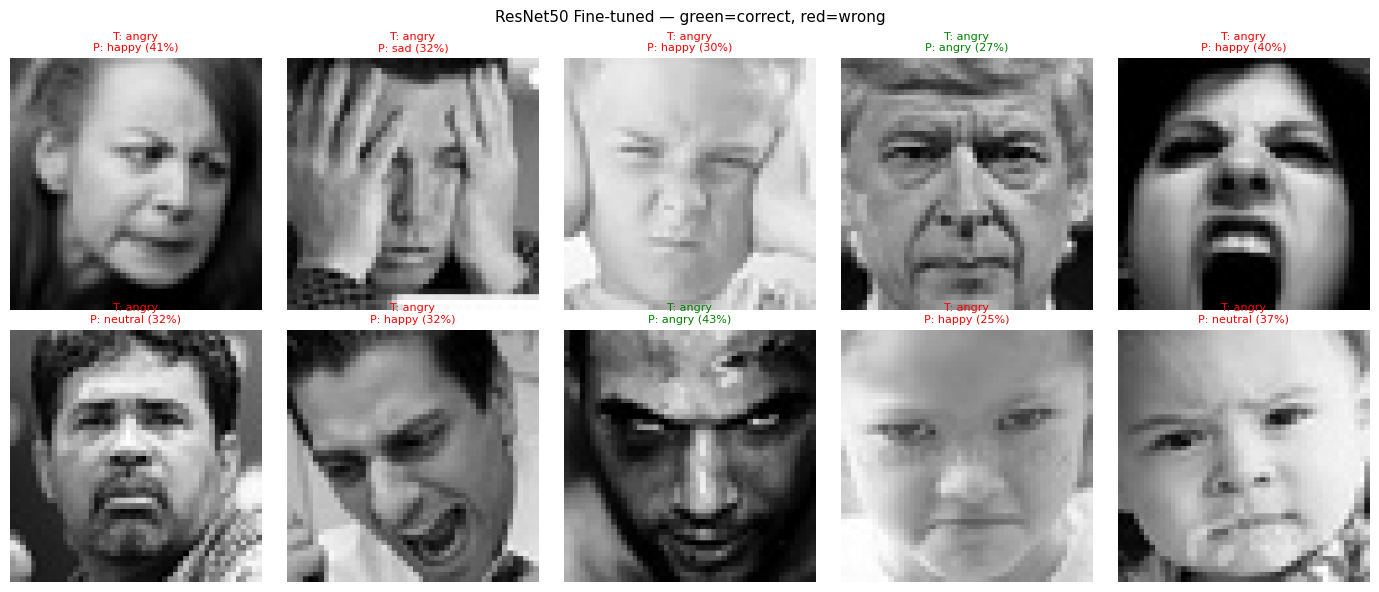

Saved: ResNet50_Fine-tuned_predictions.png


In [28]:
# Evaluate the fine-tuned ResNet50 model and show sample predictions.
resnet_true, resnet_pred = evaluate_model(resnet_model, val_gen_resnet, 'ResNet50 Fine-tuned', class_names)
show_predictions(resnet_model, val_gen_resnet, class_names, title='ResNet50 Fine-tuned')

---
## Final Model Comparison


Model                        Val Accuracy         Band
Baseline CNN                       63.83% Satisfactory
Deeper CNN (Adam)                  68.98%         Fair
Deeper CNN (SGD)                   64.58% Satisfactory
Ablation (no Dropout)              67.59%         Fair
ResNet50 Phase 1                   34.94%         Poor
ResNet50 Fine-tuned                49.77%         Pass


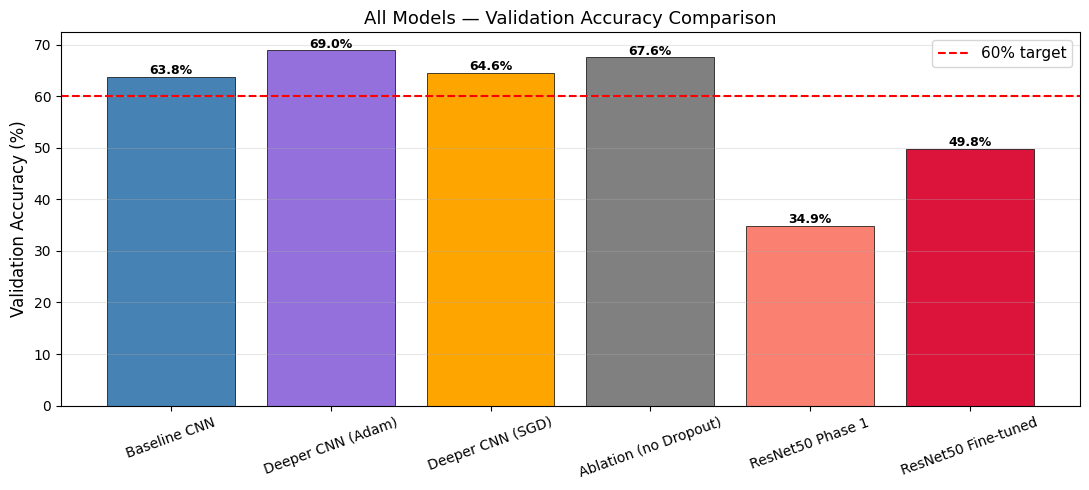

Saved: final_comparison.png


In [29]:
# Compare validation accuracy across all trained models.
models_summary = {
    'Baseline CNN':            max(baseline_history.history['val_accuracy']),
    'Deeper CNN (Adam)':       max(deeper_history.history['val_accuracy']),
    'Deeper CNN (SGD)':        max(sgd_history.history['val_accuracy']),
    'Ablation (no Dropout)':   max(ablation_history.history['val_accuracy']),
    'ResNet50 Phase 1':        max(phase1_history.history['val_accuracy']),
    'ResNet50 Fine-tuned':     max(phase2_history.history['val_accuracy']),
}

times_summary = {
    'Baseline CNN':            baseline_time,
    'Deeper CNN (Adam)':       deeper_time,
    'Deeper CNN (SGD)':        sgd_time,
    'ResNet50 Phase1+Phase2':  phase1_time + phase2_time,
}

print('\n' + '='*55)
print(f'{"Model":<28} {"Val Accuracy":>12} {"Band":>12}')
print('='*55)

def get_band(acc):
    acc *= 100
    if acc >= 90: return 'Excellent'
    if acc >= 75: return 'Good'
    if acc >= 65: return 'Fair'
    if acc >= 50: return 'Satisfactory'
    if acc >= 40: return 'Pass'
    return 'Poor'

for name, acc in models_summary.items():
    print(f'{name:<28} {acc*100:>11.2f}% {get_band(acc):>12}')
print('='*55)

# Bar chart
colors = ['steelblue', 'mediumpurple', 'orange', 'gray', 'salmon', 'crimson']
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(models_summary.keys(), [v*100 for v in models_summary.values()],
              color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(60, color='red', linestyle='--', linewidth=1.5, label='60% target')
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('All Models — Validation Accuracy Comparison', fontsize=13)
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
for bar, (name, acc) in zip(bars, models_summary.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc*100:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: final_comparison.png')

---
## Final Test Set Evaluation

=== Final Test Set Evaluation ===
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.6326 - loss: 1.0382
Deeper CNN (Adam) — Test Accuracy: 63.26%
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.4153 - loss: 1.5728
ResNet50 Fine-tuned — Test Accuracy: 41.53%

Full classification report on test set (ResNet50):
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step

  ResNet50 Test Set
              precision    recall  f1-score   support

       angry     0.4310    0.1667    0.2404       300
     disgust     1.0000    0.0100    0.0198       100
        fear     0.3062    0.2133    0.2515       300
       happy     0.4221    0.8133    0.5558       300
     neutral     0.3690    0.5400    0.4384       300
         sad     0.3034    0.2700    0.2857       300
    surprise     0.6448    0.6233    0.6339       300

    accuracy                         0.4153      1900
   macro avg     0.4967    0.3767    0.3465      1900
weighted avg     0.4437    0.4153    0.3809      1900



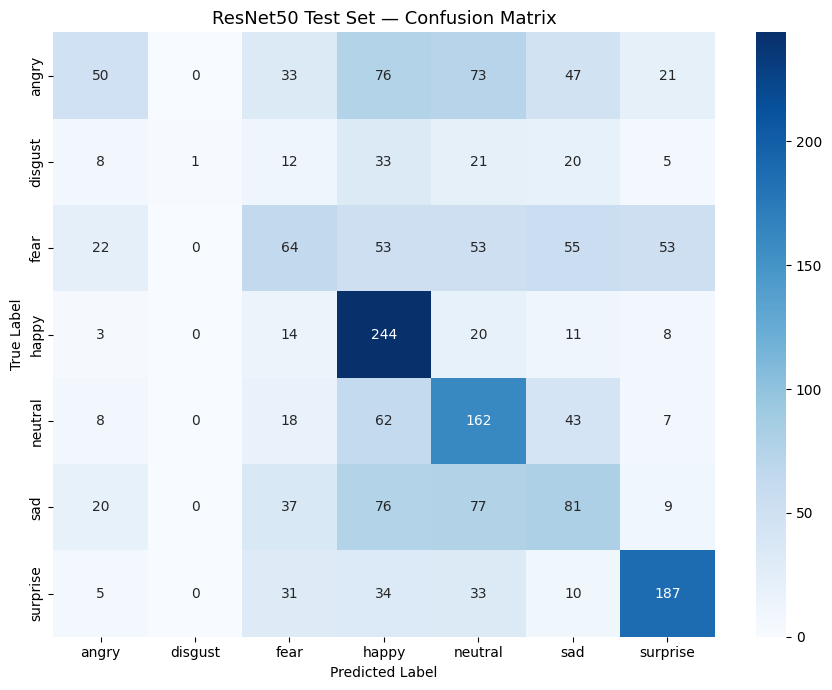

Saved: ResNet50_Test_Set_confusion.png


(array([0, 0, 0, ..., 6, 6, 6], shape=(1900,), dtype=int32),
 array([4, 2, 3, ..., 6, 6, 0], shape=(1900,)))

In [30]:
# Evaluate the best models on the held-out test set.
print('=== Final Test Set Evaluation ===')

# CNN test
test_gen.reset()
cnn_test_loss, cnn_test_acc = deeper_model.evaluate(test_gen, verbose=1)
print(f'Deeper CNN (Adam) — Test Accuracy: {cnn_test_acc*100:.2f}%')

# ResNet test
test_gen_resnet.reset()
resnet_test_loss, resnet_test_acc = resnet_model.evaluate(test_gen_resnet, verbose=1)
print(f'ResNet50 Fine-tuned — Test Accuracy: {resnet_test_acc*100:.2f}%')

print('\nFull classification report on test set (ResNet50):')
evaluate_model(resnet_model, test_gen_resnet, 'ResNet50 Test Set', class_names)

---
## Save Models

In [31]:
# Save the trained model files and list generated artifacts.
baseline_model.save('baseline_cnn_final.keras')
deeper_model.save('deeper_cnn_adam_final.keras')
sgd_model.save('deeper_cnn_sgd_final.keras')
resnet_model.save('resnet50_finetuned_final.keras')

print('All models saved!')
print('Files:')
for f in os.listdir('.'):
    if f.endswith('.keras') or f.endswith('.png'):
        size_mb = os.path.getsize(f) / (1024*1024)
        print(f'  {f:<45} {size_mb:>6.1f} MB')

All models saved!
Files:
  Deeper_CNN_Adam_curves.png                       0.1 MB
  baseline_cnn_final.keras                        15.1 MB
  deeper_cnn_adam_final.keras                     28.6 MB
  best_resnet_phase2.keras                       206.9 MB
  best_resnet_phase1.keras                        96.7 MB
  Baseline_CNN_curves.png                          0.1 MB
  sample_images.png                                0.2 MB
  resnet50_finetuned_final.keras                 206.9 MB
  best_ablation.keras                             31.9 MB
  best_baseline_cnn.keras                         15.1 MB
  ResNet50_Fine-tuned_confusion.png                0.1 MB
  Baseline_CNN_predictions.png                     0.1 MB
  deeper_cnn_sgd_final.keras                      19.1 MB
  best_deeper_cnn_sgd.keras                       19.1 MB
  Deeper_CNN_Adam_confusion.png                    0.1 MB
  class_distribution.png                           0.1 MB
  Ablation_No_Dropout_curves.png               